In [1]:
# Import 
import os
import numpy as np
from scipy.spatial import ConvexHull
from scipy.optimize import linear_sum_assignment
from itertools import permutations
import time
import pandas as pd
from joblib import dump, load
from pathlib import Path

## sourceXray
from src.sourceXray_BJ import sourceXray, compute_C, solve_H_right_inverse
from src.utils import *
from src.simulate_nmf import simulate_dataset

## N-FINDR
from src.NFINDR import nfindr_BJ

## W 
import pysptools.abundance_maps as amp
nnls = amp.NNLS() # nonnegative constrained least squares and then row-normalize

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
# setting
K = 3
J = 8
n_reps = 50

# path 
outdir = Path("results/sims")
outdir.mkdir(parents=True, exist_ok=True)

In [4]:
# log e_ij = u_i + v_j + tau*eta_ij
# tau = 0: exactly separable; small tau > 0: weakly separable; large tau > 0: strongly nonseparable 
# Y_ij = e_ij*Yhat_ij
# u_i = log a_i; v_j = log b_j 
# assume E(a_i) = 1
# u_i = log a_i ~ N(-sigma_u^2/2, sigma_u^2)
# v_j ~ N(0, sigma_v^2)
# eta_ij ~ N(0,1)

def add_log_multiplicative_error(
    Yhat,
    sigma_u=0.3,
    sigma_v=0.3,
    tau=0.0,
    seed=None,
):
    """
    Generate observed data under
        log eps_ij = u_i + v_j + tau * eta_ij
        Y_obs_ij   = eps_ij * Yhat_ij
    """
    rng = np.random.default_rng(seed)
    n, J = Yhat.shape

    mu_u = -0.5 * sigma_u**2 
    
    u = rng.normal(loc=mu_u, scale=sigma_u, size=n)
    v = rng.normal(loc=0.0, scale=sigma_v, size=J)
    eta = rng.normal(loc=0.0, scale=1.0, size=(n, J))

    log_eps = u[:, None] + v[None, :] + tau * eta
    eps = np.exp(log_eps)
    Y_obs = Yhat * eps

    return Y_obs, eps, u, v, eta

In [5]:
# nonseparable noise strengths
tau_list = [0.0, 0.1, 0.3, 0.6]

# log-error scales
sigma_u = 0.3   # sample-level multiplicative error
sigma_v = 0.3   # variable-level multiplicative error

In [ ]:
# # data dimensions to try
# n_list = [100, 300]

# # container to hold *all* results in memory
# # results[n][tau] 
# results = {}

# for n in n_list:
#     print(f"\n=== Running experiments for n = {n} ===\n")
#     results[n] = {}

#     for tau in tau_list:
#         print(f"\n--- Running experiments for n = {n}, tau = {tau} ---\n")
    
#         # allocate per-(n,tau) arrays
#         per_nt = {
#             # time
#             "time_sourceXray": np.zeros(n_reps),
#             "time_nfindr": np.zeros(n_reps),

#             # H metrics
#             "H_rmssad_sourceXray": np.zeros(n_reps),
#             "H_fro_sourceXray": np.zeros(n_reps),
#             "H_nrmse_sourceXray": np.zeros(n_reps),
#             "H_rmssad_nfindr": np.zeros(n_reps),
#             "H_fro_nfindr": np.zeros(n_reps),
#             "H_nrmse_nfindr": np.zeros(n_reps),

#             # C metrics
#             "C_fro_sourceXray": np.zeros(n_reps),
#             "C_nrmse_sourceXray": np.zeros(n_reps),
#             "C_fro_nfindr": np.zeros(n_reps),
#             "C_nrmse_nfindr": np.zeros(n_reps),
#         }

#         est_per_nt = {
#             "C_hat_sourceXray": np.empty((n_reps, J, K), dtype=float),
#             "C_hat_nfindr": np.empty((n_reps, J, K), dtype=float),
#             "H_star_hat_sourceXray": np.empty((n_reps, K, J), dtype=float),
#             "H_star_hat_nfindr": np.empty((n_reps, K, J), dtype=float),

#             # truths
#             "C": np.empty((n_reps, J, K), dtype=float),
#             "H_star": np.empty((n_reps, K, J), dtype=float),
#         }

#         for rep in range(n_reps):
#             print(f"n={n}, tau={tau}, rep {rep+1}/{n_reps}", flush=True)    

#             seed = n + rep + int(10 * tau)
        
#             # -----------------------------
#             # 1) simulate latent data
#             # -----------------------------
#             Yhat, Yhat_star, r_true, H, H_star, W, mu, W_tilde, mu_tilde, W_star, C, C_alt = \
#                 simulate_dataset(n=n, K=K, J=J, seed=seed, process="ar1")

#             est_per_nt["C"][rep] = C
#             est_per_nt["H_star"][rep] = H_star

#             # -----------------------------
#             # 2) inject multiplicative error
#             #    log eps_ij = u_i + v_j + tau * eta_ij
#             # -----------------------------
#             Y, eps, u, v, eta = add_log_multiplicative_error(
#                 Yhat,
#                 sigma_u=sigma_u,
#                 sigma_v=sigma_v,
#                 tau=tau,
#                 seed=seed
#             )

#             # ---------- sourceXray ----------
#             t0 = time.time()
#             H_star_hat, W_tilde_hat, mu_tilde_hat, C_hat, logvol_hat = sourceXray(Y, K, seed=seed, prune=False, verbose=False)[0]
#             t1 = time.time()
#             per_nt["time_sourceXray"][rep] = t1 - t0

#             # permute to match truth
#             H_star_hat_perm, mu_tilde_hat_perm, C_hat_perm, _ = \
#                 permute_estimates_to_match_truth(H_star, H_star_hat, mu_tilde_hat, C_hat)
#             est_per_nt["C_hat_sourceXray"][rep] = C_hat_perm
#             est_per_nt["H_star_hat_sourceXray"][rep] = H_star_hat_perm

#             # metrics (H)
#             per_nt["H_rmssad_sourceXray"][rep] = rms_sad(H_star, H_star_hat_perm)['rms_sad']
#             per_nt["H_fro_sourceXray"][rep] = frobenius_dist(H_star, H_star_hat_perm, relative=True)
#             per_nt["H_nrmse_sourceXray"][rep] = nrmse(H_star, H_star_hat_perm)['nrmse']

#             # metrics (C)
#             per_nt["C_fro_sourceXray"][rep] = frobenius_dist(C, C_hat_perm, relative=True)
#             per_nt["C_nrmse_sourceXray"][rep] = nrmse(C, C_hat_perm)['nrmse']

#             # ---------- N-FINDR ----------
#             r = Y.sum(axis=1, keepdims=True)
#             Y_star = Y / r
#             t0 = time.time()
#             H_star_hat_nfindr, *_ = nfindr_BJ(Y_star, K, max_iter=5, seed=seed, normalize=False, init='atgp')
#             W_star_hat_nfindr, _, _ = solve_H_right_inverse(Y_star, H_star_hat_nfindr)
#             W_tilde_hat_nfindr = W_star_hat_nfindr * r
#             mu_tilde_hat_nfindr = W_tilde_hat_nfindr.mean(axis=0)
#             C_hat_nfindr = compute_C(mu_tilde_hat_nfindr, H_star_hat_nfindr)
#             t1 = time.time()
#             per_nt["time_nfindr"][rep] = t1 - t0

#             H_star_hat_perm_nfindr, mu_tilde_hat_perm_nfindr, C_hat_perm_nfindr, _ = \
#                 permute_estimates_to_match_truth(H_star, H_star_hat_nfindr, mu_tilde_hat_nfindr, C_hat_nfindr)
#             est_per_nt["C_hat_nfindr"][rep] = C_hat_perm_nfindr
#             est_per_nt["H_star_hat_nfindr"][rep] = H_star_hat_perm_nfindr

#             # metrics (H)
#             per_nt["H_rmssad_nfindr"][rep] = rms_sad(H_star, H_star_hat_perm_nfindr)['rms_sad']
#             per_nt["H_fro_nfindr"][rep] = frobenius_dist(H_star, H_star_hat_perm_nfindr, relative=True)
#             per_nt["H_nrmse_nfindr"][rep] = nrmse(H_star, H_star_hat_perm_nfindr)['nrmse']

#             # metrics (C)
#             per_nt["C_fro_nfindr"][rep] = frobenius_dist(C, C_hat_perm_nfindr, relative=True)
#             per_nt["C_nrmse_nfindr"][rep] = nrmse(C, C_hat_perm_nfindr)['nrmse']

#         results[n][tau] = {
#             "metrics": per_nt,
#             "estimates": est_per_nt,
#         }

#         # save  
#         dump(
#             results[n][tau],
#             outdir / f"sourceXray_error_sims_ar1W_RinvH_J{J}K{K}_n{n}_tau{str(tau).replace('.', 'p')}.joblib"
#         )

In [ ]:
# # data dimensions to try
# n_list = [1500, 10000, 100000, 500000]

# for n in n_list:
#     print(f"\n=== Running experiments for n = {n} ===\n")
#     results[n] = {}

#     for tau in tau_list:
#         print(f"\n--- Running experiments for n = {n}, tau = {tau} ---\n")
    
#         # allocate per-(n,tau) arrays
#         per_nt = {
#             # time
#             "time_nfindr": np.zeros(n_reps),

#             # H metrics
#             "H_rmssad_nfindr": np.zeros(n_reps),
#             "H_fro_nfindr": np.zeros(n_reps),
#             "H_nrmse_nfindr": np.zeros(n_reps),

#             # C metrics
#             "C_fro_nfindr": np.zeros(n_reps),
#             "C_nrmse_nfindr": np.zeros(n_reps),
#         }

#         est_per_nt = {
#             "C_hat_nfindr": np.empty((n_reps, J, K), dtype=float),
#             "H_star_hat_nfindr": np.empty((n_reps, K, J), dtype=float),

#             # truths
#             "C": np.empty((n_reps, J, K), dtype=float),
#             "H_star": np.empty((n_reps, K, J), dtype=float),
#         }

#         for rep in range(n_reps):
#             print(f"n={n}, tau={tau}, rep {rep+1}/{n_reps}", flush=True)    

#             seed = n + rep + int(10 * tau)
        
#             # -----------------------------
#             # 1) simulate latent data
#             # -----------------------------
#             Yhat, Yhat_star, r_true, H, H_star, W, mu, W_tilde, mu_tilde, W_star, C, C_alt = \
#                 simulate_dataset(n=n, K=K, J=J, seed=seed, process="ar1")

#             est_per_nt["C"][rep] = C
#             est_per_nt["H_star"][rep] = H_star

#             # -----------------------------
#             # 2) inject multiplicative error
#             #    log eps_ij = u_i + v_j + tau * eta_ij
#             # -----------------------------
#             Y, eps, u, v, eta = add_log_multiplicative_error(
#                 Yhat,
#                 sigma_u=sigma_u,
#                 sigma_v=sigma_v,
#                 tau=tau,
#                 seed=seed
#             )

#             # ---------- N-FINDR ----------
#             r = Y.sum(axis=1, keepdims=True)
#             Y_star = Y / r
#             t0 = time.time()
#             H_star_hat_nfindr, *_ = nfindr_BJ(Y_star, K, max_iter=5, seed=seed, normalize=False, init='atgp')
#             W_star_hat_nfindr, _, _ = solve_H_right_inverse(Y_star, H_star_hat_nfindr)
#             W_tilde_hat_nfindr = W_star_hat_nfindr * r
#             mu_tilde_hat_nfindr = W_tilde_hat_nfindr.mean(axis=0)
#             C_hat_nfindr = compute_C(mu_tilde_hat_nfindr, H_star_hat_nfindr)
#             t1 = time.time()
#             per_nt["time_nfindr"][rep] = t1 - t0

#             H_star_hat_perm_nfindr, mu_tilde_hat_perm_nfindr, C_hat_perm_nfindr, _ = \
#                 permute_estimates_to_match_truth(H_star, H_star_hat_nfindr, mu_tilde_hat_nfindr, C_hat_nfindr)
#             est_per_nt["C_hat_nfindr"][rep] = C_hat_perm_nfindr
#             est_per_nt["H_star_hat_nfindr"][rep] = H_star_hat_perm_nfindr

#             # metrics (H)
#             per_nt["H_rmssad_nfindr"][rep] = rms_sad(H_star, H_star_hat_perm_nfindr)['rms_sad']
#             per_nt["H_fro_nfindr"][rep] = frobenius_dist(H_star, H_star_hat_perm_nfindr, relative=True)
#             per_nt["H_nrmse_nfindr"][rep] = nrmse(H_star, H_star_hat_perm_nfindr)['nrmse']

#             # metrics (C)
#             per_nt["C_fro_nfindr"][rep] = frobenius_dist(C, C_hat_perm_nfindr, relative=True)
#             per_nt["C_nrmse_nfindr"][rep] = nrmse(C, C_hat_perm_nfindr)['nrmse']

#         results[n][tau] = {
#             "metrics": per_nt,
#             "estimates": est_per_nt,
#         }

#         # save  
#         dump(
#             results[n][tau],
#             outdir / f"sourceXray_error_sims_ar1W_RinvH_J{J}K{K}_n{n}_tau{str(tau).replace('.', 'p')}.joblib"
#         )

In [ ]:
# data dimensions to try
n_list = [1500, 10000]

for n in n_list:
    print(f"\n=== Running experiments for n = {n} ===\n")

    for tau in tau_list:
        print(f"\n--- Running experiments for n = {n}, tau = {tau} ---\n")
    
        # allocate per-(n,tau) arrays
        per_nt = {
            # time
            "time_sourceXray": np.zeros(n_reps),
            "time_nfindr": results[n][tau]["metrics"]["time_nfindr"],

            # H metrics
            "H_rmssad_sourceXray": np.zeros(n_reps),
            "H_fro_sourceXray": np.zeros(n_reps),
            "H_nrmse_sourceXray": np.zeros(n_reps),
            "H_rmssad_nfindr": results[n][tau]["metrics"]["H_rmssad_nfindr"],
            "H_fro_nfindr": results[n][tau]["metrics"]["H_fro_nfindr"],
            "H_nrmse_nfindr": results[n][tau]["metrics"]["H_nrmse_nfindr"],

            # C metrics
            "C_fro_sourceXray": np.zeros(n_reps),
            "C_nrmse_sourceXray": np.zeros(n_reps),
            "C_fro_nfindr": results[n][tau]["metrics"]["C_fro_nfindr"],
            "C_nrmse_nfindr": results[n][tau]["metrics"]["C_nrmse_nfindr"],
        }

        est_per_nt = {
            "C_hat_sourceXray": np.empty((n_reps, J, K), dtype=float),
            "H_star_hat_sourceXray": np.empty((n_reps, K, J), dtype=float),
            "C_hat_nfindr": results[n][tau]["estimates"]["C_hat_nfindr"],
            "H_star_hat_nfindr": results[n][tau]["estimates"]["H_star_hat_nfindr"],

            # truths
            "C": results[n][tau]["estimates"]["C"],
            "H_star": results[n][tau]["estimates"]["H_star"],
        }

        for rep in range(n_reps):
            print(f"n={n}, tau={tau}, rep {rep+1}/{n_reps}", flush=True)    

            seed = n + rep + int(10 * tau)
        
            # -----------------------------
            # 1) simulate latent data
            # -----------------------------
            Yhat, Yhat_star, r_true, H, H_star, W, mu, W_tilde, mu_tilde, W_star, C, C_alt = \
                simulate_dataset(n=n, K=K, J=J, seed=seed, process="ar1")

            est_per_nt["C"][rep] = C
            est_per_nt["H_star"][rep] = H_star

            # -----------------------------
            # 2) inject multiplicative error
            #    log eps_ij = u_i + v_j + tau * eta_ij
            # -----------------------------
            Y, eps, u, v, eta = add_log_multiplicative_error(
                Yhat,
                sigma_u=sigma_u,
                sigma_v=sigma_v,
                tau=tau,
                seed=seed
            )

            # ---------- sourceXray ----------
            t0 = time.time()
            H_star_hat, W_tilde_hat, mu_tilde_hat, C_hat, logvol_hat = sourceXray(Y, K, seed=seed, 
                                                                                  prune=True, min_K = 150*K,
                                                                                  verbose=False)[0]
            t1 = time.time()
            per_nt["time_sourceXray"][rep] = t1 - t0

            # permute to match truth
            H_star_hat_perm, mu_tilde_hat_perm, C_hat_perm, _ = \
                permute_estimates_to_match_truth(H_star, H_star_hat, mu_tilde_hat, C_hat)
            est_per_nt["C_hat_sourceXray"][rep] = C_hat_perm
            est_per_nt["H_star_hat_sourceXray"][rep] = H_star_hat_perm

            # metrics (H)
            per_nt["H_rmssad_sourceXray"][rep] = rms_sad(H_star, H_star_hat_perm)['rms_sad']
            per_nt["H_fro_sourceXray"][rep] = frobenius_dist(H_star, H_star_hat_perm, relative=True)
            per_nt["H_nrmse_sourceXray"][rep] = nrmse(H_star, H_star_hat_perm)['nrmse']

            # metrics (C)
            per_nt["C_fro_sourceXray"][rep] = frobenius_dist(C, C_hat_perm, relative=True)
            per_nt["C_nrmse_sourceXray"][rep] = nrmse(C, C_hat_perm)['nrmse']

            # ---------- N-FINDR ----------
            r = Y.sum(axis=1, keepdims=True)
            Y_star = Y / r
            t0 = time.time()
            H_star_hat_nfindr, *_ = nfindr_BJ(Y_star, K, max_iter=5, seed=seed, normalize=False, init='atgp')
            W_star_hat_nfindr, _, _ = solve_H_right_inverse(Y_star, H_star_hat_nfindr)
            W_tilde_hat_nfindr = W_star_hat_nfindr * r
            mu_tilde_hat_nfindr = W_tilde_hat_nfindr.mean(axis=0)
            C_hat_nfindr = compute_C(mu_tilde_hat_nfindr, H_star_hat_nfindr)
            t1 = time.time()
            per_nt["time_nfindr"][rep] = t1 - t0

            H_star_hat_perm_nfindr, mu_tilde_hat_perm_nfindr, C_hat_perm_nfindr, _ = \
                permute_estimates_to_match_truth(H_star, H_star_hat_nfindr, mu_tilde_hat_nfindr, C_hat_nfindr)
            est_per_nt["C_hat_nfindr"][rep] = C_hat_perm_nfindr
            est_per_nt["H_star_hat_nfindr"][rep] = H_star_hat_perm_nfindr

            # metrics (H)
            per_nt["H_rmssad_nfindr"][rep] = rms_sad(H_star, H_star_hat_perm_nfindr)['rms_sad']
            per_nt["H_fro_nfindr"][rep] = frobenius_dist(H_star, H_star_hat_perm_nfindr, relative=True)
            per_nt["H_nrmse_nfindr"][rep] = nrmse(H_star, H_star_hat_perm_nfindr)['nrmse']

            # metrics (C)
            per_nt["C_fro_nfindr"][rep] = frobenius_dist(C, C_hat_perm_nfindr, relative=True)
            per_nt["C_nrmse_nfindr"][rep] = nrmse(C, C_hat_perm_nfindr)['nrmse']

        results[n][tau] = {
            "metrics": per_nt,
            "estimates": est_per_nt,
        }

        # save  
        dump(
            results[n][tau],
            outdir / f"sourceXray_error_sims_ar1W_RinvH_J{J}K{K}_n{n}_tau{str(tau).replace('.', 'p')}.joblib"
        )


=== Running experiments for n = 1500 ===


--- Running experiments for n = 1500, tau = 0.0 ---

n=1500, tau=0.0, rep 1/50
n=1500, tau=0.0, rep 2/50
n=1500, tau=0.0, rep 3/50
n=1500, tau=0.0, rep 4/50
n=1500, tau=0.0, rep 5/50
n=1500, tau=0.0, rep 6/50
n=1500, tau=0.0, rep 7/50
n=1500, tau=0.0, rep 8/50
n=1500, tau=0.0, rep 9/50
n=1500, tau=0.0, rep 10/50
n=1500, tau=0.0, rep 11/50
n=1500, tau=0.0, rep 12/50
n=1500, tau=0.0, rep 13/50
n=1500, tau=0.0, rep 14/50
n=1500, tau=0.0, rep 15/50
n=1500, tau=0.0, rep 16/50
n=1500, tau=0.0, rep 17/50
n=1500, tau=0.0, rep 18/50
n=1500, tau=0.0, rep 19/50
n=1500, tau=0.0, rep 20/50
n=1500, tau=0.0, rep 21/50
n=1500, tau=0.0, rep 22/50
n=1500, tau=0.0, rep 23/50
n=1500, tau=0.0, rep 24/50
n=1500, tau=0.0, rep 25/50
n=1500, tau=0.0, rep 26/50
n=1500, tau=0.0, rep 27/50
n=1500, tau=0.0, rep 28/50
n=1500, tau=0.0, rep 29/50
n=1500, tau=0.0, rep 30/50
n=1500, tau=0.0, rep 31/50
n=1500, tau=0.0, rep 32/50
n=1500, tau=0.0, rep 33/50
n=1500, tau=0.0, rep 

In [50]:
# data dimensions to try
n_list = [100000, 500000]

for n in n_list:
    print(f"\n=== Running experiments for n = {n} ===\n")

    for tau in tau_list:
        print(f"\n--- Running experiments for n = {n}, tau = {tau} ---\n")
    
        # allocate per-(n,tau) arrays
        per_nt = {
            # time
            "time_sourceXray": np.zeros(n_reps),
            "time_nfindr": results[n][tau]["metrics"]["time_nfindr"],

            # H metrics
            "H_rmssad_sourceXray": np.zeros(n_reps),
            "H_fro_sourceXray": np.zeros(n_reps),
            "H_nrmse_sourceXray": np.zeros(n_reps),
            "H_rmssad_nfindr": results[n][tau]["metrics"]["H_rmssad_nfindr"],
            "H_fro_nfindr": results[n][tau]["metrics"]["H_fro_nfindr"],
            "H_nrmse_nfindr": results[n][tau]["metrics"]["H_nrmse_nfindr"],

            # C metrics
            "C_fro_sourceXray": np.zeros(n_reps),
            "C_nrmse_sourceXray": np.zeros(n_reps),
            "C_fro_nfindr": results[n][tau]["metrics"]["C_fro_nfindr"],
            "C_nrmse_nfindr": results[n][tau]["metrics"]["C_nrmse_nfindr"],
        }

        est_per_nt = {
            "C_hat_sourceXray": np.empty((n_reps, J, K), dtype=float),
            "H_star_hat_sourceXray": np.empty((n_reps, K, J), dtype=float),
            "C_hat_nfindr": results[n][tau]["estimates"]["C_hat_nfindr"],
            "H_star_hat_nfindr": results[n][tau]["estimates"]["H_star_hat_nfindr"],

            # truths
            "C": results[n][tau]["estimates"]["C"],
            "H_star": results[n][tau]["estimates"]["H_star"],
        }

        for rep in range(n_reps):
            print(f"n={n}, tau={tau}, rep {rep+1}/{n_reps}", flush=True)    

            seed = n + rep + int(10 * tau)
        
            # -----------------------------
            # 1) simulate latent data
            # -----------------------------
            Yhat, Yhat_star, r_true, H, H_star, W, mu, W_tilde, mu_tilde, W_star, C, C_alt = \
                simulate_dataset(n=n, K=K, J=J, seed=seed, process="ar1")

            est_per_nt["C"][rep] = C
            est_per_nt["H_star"][rep] = H_star

            # -----------------------------
            # 2) inject multiplicative error
            #    log eps_ij = u_i + v_j + tau * eta_ij
            # -----------------------------
            Y, eps, u, v, eta = add_log_multiplicative_error(
                Yhat,
                sigma_u=sigma_u,
                sigma_v=sigma_v,
                tau=tau,
                seed=seed
            )

            # ---------- sourceXray ----------
            t0 = time.time()
            H_star_hat, W_tilde_hat, mu_tilde_hat, C_hat, logvol_hat = sourceXray(Y, K, seed=seed, 
                                                                                  candidate_method="random", 
                                                                                  T=20000, topk=1, max_K=1000*K, 
                                                                                  prune=True, min_K = 150*K, 
                                                                                  verbose=False)[0]
            t1 = time.time()
            per_nt["time_sourceXray"][rep] = t1 - t0

            # permute to match truth
            H_star_hat_perm, mu_tilde_hat_perm, C_hat_perm, _ = \
                permute_estimates_to_match_truth(H_star, H_star_hat, mu_tilde_hat, C_hat)
            est_per_nt["C_hat_sourceXray"][rep] = C_hat_perm
            est_per_nt["H_star_hat_sourceXray"][rep] = H_star_hat_perm

            # metrics (H)
            per_nt["H_rmssad_sourceXray"][rep] = rms_sad(H_star, H_star_hat_perm)['rms_sad']
            per_nt["H_fro_sourceXray"][rep] = frobenius_dist(H_star, H_star_hat_perm, relative=True)
            per_nt["H_nrmse_sourceXray"][rep] = nrmse(H_star, H_star_hat_perm)['nrmse']

            # metrics (C)
            per_nt["C_fro_sourceXray"][rep] = frobenius_dist(C, C_hat_perm, relative=True)
            per_nt["C_nrmse_sourceXray"][rep] = nrmse(C, C_hat_perm)['nrmse']

        results[n][tau] = {
            "metrics": per_nt,
            "estimates": est_per_nt,
        }

        # save  
        dump(
            results[n][tau],
            outdir / f"sourceXray_error_sims_ar1W_RinvH_J{J}K{K}_n{n}_tau{str(tau).replace('.', 'p')}.joblib"
        )


=== Running experiments for n = 100000 ===


--- Running experiments for n = 100000, tau = 0.0 ---

n=100000, tau=0.0, rep 1/50
n=100000, tau=0.0, rep 2/50
n=100000, tau=0.0, rep 3/50
n=100000, tau=0.0, rep 4/50
n=100000, tau=0.0, rep 5/50
n=100000, tau=0.0, rep 6/50
n=100000, tau=0.0, rep 7/50
n=100000, tau=0.0, rep 8/50
n=100000, tau=0.0, rep 9/50
n=100000, tau=0.0, rep 10/50
n=100000, tau=0.0, rep 11/50
n=100000, tau=0.0, rep 12/50
n=100000, tau=0.0, rep 13/50
n=100000, tau=0.0, rep 14/50
n=100000, tau=0.0, rep 15/50
n=100000, tau=0.0, rep 16/50
n=100000, tau=0.0, rep 17/50
n=100000, tau=0.0, rep 18/50
n=100000, tau=0.0, rep 19/50
n=100000, tau=0.0, rep 20/50
n=100000, tau=0.0, rep 21/50
n=100000, tau=0.0, rep 22/50
n=100000, tau=0.0, rep 23/50
n=100000, tau=0.0, rep 24/50
n=100000, tau=0.0, rep 25/50
n=100000, tau=0.0, rep 26/50
n=100000, tau=0.0, rep 27/50
n=100000, tau=0.0, rep 28/50
n=100000, tau=0.0, rep 29/50
n=100000, tau=0.0, rep 30/50
n=100000, tau=0.0, rep 31/50
n=100000,

In [51]:
dump(results, outdir/f"sourceXray_error_sims_ar1W_RinvH_J{J}K{K}_v2.joblib")

['results/sims/sourceXray_error_sims_ar1W_RinvH_J8K3_v2.joblib']

In [ ]:
# dump(results, outdir/f"sourceXray_error_sims_ar1W_RinvH_J{J}K{K}.joblib")

['results/sims/sourceXray_error_sims_ar1W_RinvH_J8K3.joblib']

In [14]:
results = load(f"results/sims/sourceXray_error_sims_ar1W_RinvH_J{J}K{K}.joblib")

# Collect the union of metric keys across all (n, tau)
all_metric_keys = sorted({
    k
    for n, tau_dict in results.items()
    for tau, bundle in tau_dict.items()
    for k in bundle["metrics"].keys()
})

# Long table: one row per (n, tau, rep), columns for all metrics
records = []
for n, tau_dict in results.items():
    for tau, bundle in tau_dict.items():
        per_nt = bundle["metrics"]
        
        # infer number of reps from first metric array
        n_reps_here = len(next(iter(per_nt.values())))
        
        for rep in range(n_reps_here):
            rec = {"n": n, "tau": tau, "rep": rep}
            for mk in all_metric_keys:
                arr = per_nt.get(mk, None)
                rec[mk] = arr[rep] if arr is not None and rep < len(arr) else np.nan
            records.append(rec)

df_long = (
    pd.DataFrame.from_records(records)
    .sort_values(["n", "tau", "rep"])
    .reset_index(drop=True)
)

# Per-(n, tau) summary: mean and std across reps
metric_cols = [c for c in df_long.columns if c not in ("n", "tau", "rep")]

summary_mean = (
    df_long.groupby(["n", "tau"], as_index=False)[metric_cols]
    .mean(numeric_only=True)
    .rename(columns={c: f"{c}_mean" for c in metric_cols})
)

summary_std = (
    df_long.groupby(["n", "tau"], as_index=False)[metric_cols]
    .std(ddof=1, numeric_only=True)
    .rename(columns={c: f"{c}_std" for c in metric_cols})
)

# merge mean and std on (n, tau)
df_summary = summary_mean.merge(summary_std, on=["n", "tau"], how="left")

In [17]:
print("\nPer-(n, tau) summary:")
print(df_summary[["n", "tau", "time_nfindr_mean", "time_nfindr_std", "time_sourceXray_mean", "time_sourceXray_std", 
                  "C_fro_nfindr_mean", "C_fro_nfindr_std", "C_fro_sourceXray_mean", "C_fro_sourceXray_std",
                  "C_nrmse_nfindr_mean", "C_nrmse_nfindr_std", "C_nrmse_sourceXray_mean", "C_nrmse_sourceXray_std"]])


Per-(n, tau) summary:
         n  tau  time_nfindr_mean  time_nfindr_std  time_sourceXray_mean  \
0      100  0.0          0.004304         0.001083              0.002033   
1      100  0.1          0.004247         0.000739              1.000035   
2      100  0.3          0.004188         0.000818              0.955832   
3      100  0.6          0.004012         0.000913              0.876990   
4      300  0.0          0.012411         0.004020              0.002520   
5      300  0.1          0.012534         0.002984             10.582950   
6      300  0.3          0.012349         0.002729              9.674102   
7      300  0.6          0.011557         0.002510              8.185085   
8     1500  0.0          0.056559         0.008538                   NaN   
9     1500  0.1          0.058546         0.013066                   NaN   
10    1500  0.3          0.059573         0.012335                   NaN   
11    1500  0.6          0.057205         0.009196               

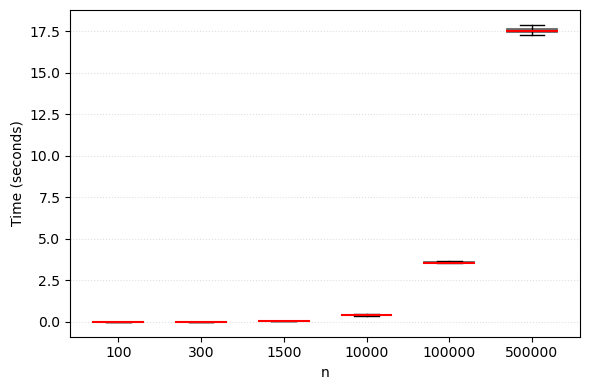

In [19]:
# Build a time-only long table from df_long
time_cols = [c for c in df_long.columns if c.startswith("time_")]
df_time = df_long.melt(
    id_vars=["n", "rep"],
    value_vars=time_cols,
    var_name="algorithm",
    value_name="value",
).dropna(subset=["value"])
df_time["algorithm"] = (
    df_time["algorithm"]
      .str.replace("^time_", "", regex=True)
      .replace({"nfindr": "Greedy search", 
                "sourceXray": "Exhaustive search"})   # <- rename for plotting
)
facet_boxplots(
    df=df_time,
    desired_algos=("Greedy search",),
    showfliers=False,
    figsize_per_panel=(6, 4),
    free_y=True,
    # savepath=outdir/"figure/sourceXray_convergence_sims_ar1W_RinvH_J8K3_time.pdf", 
    metric_label="Time (seconds)",
    title=False
)

In [25]:
# Build a C_fro-only long table from df_long
C_fro_cols = [c for c in df_long.columns if c.startswith("C_fro_")]
df_C_fro = (
    df_long.melt(
        id_vars=["n", "tau", "rep"],
        value_vars=C_fro_cols,
        var_name="algorithm",
        value_name="value",
    )
    .dropna(subset=["value"])
)
df_C_fro["algorithm"] = (
    df_C_fro["algorithm"]
      .str.replace("^C_fro_", "", regex=True)
      .replace({"nfindr": "Greedy search", 
                "sourceXray": "Exhaustive search"})
)
# df_C_fro

# summary by n, tau, algorithm
df_C_fro_summary = (
    df_C_fro
    .groupby(["n", "tau", "algorithm"], as_index=False)["value"]
    .agg(mean_value="mean", median_value="median")
    .sort_values(["n", "tau", "algorithm"])
    .reset_index(drop=True)
)
df_C_fro_summary

,n,tau,algorithm,mean_value,median_value
0,100,0.0,Exhaustive search,0.319131,0.318711
1,100,0.0,Greedy search,0.323447,0.322959
2,100,0.1,Exhaustive search,0.355428,0.334251
3,100,0.1,Greedy search,0.366931,0.346949
4,100,0.3,Exhaustive search,0.476385,0.463357
5,100,0.3,Greedy search,0.473706,0.459220
6,100,0.6,Exhaustive search,0.641285,0.641451
7,100,0.6,Greedy search,0.640357,0.632465
8,300,0.0,Exhaustive search,0.252880,0.243097
9,300,0.0,Greedy search,0.252880,0.243097


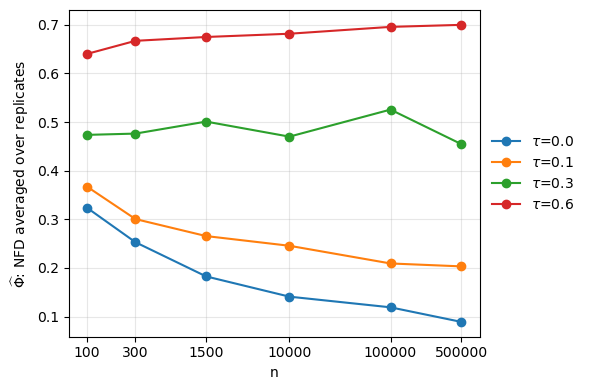

In [38]:
# make sure tau is ordered nicely
df_C_fro_plot = df_C_fro_summary[df_C_fro_summary["algorithm"] == "Greedy search"].copy()
df_C_fro_plot = df_C_fro_plot.sort_values(["tau", "n"])
n_list = [100, 300, 1500, 10000, 100000, 500000]

fig, ax = plt.subplots(figsize=(6, 4))

for tau in tau_list:
    sub = df_C_fro_plot[df_C_fro_plot["tau"] == tau].sort_values("n")
    ax.plot(sub["n"], sub["mean_value"], marker="o", label=rf"$\tau$={tau}")

ax.set_xscale("log")
ax.set_xticks(n_list)
ax.set_xticklabels(n_list)
ax.minorticks_off()   # removes the little ticks between n values
ax.set_xlabel("n")

ax.set_ylabel("$\widehat{\Phi}$: NFD averaged over replicates")
ax.grid(True, alpha=0.3)

# legend outside
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)

plt.tight_layout()
plt.show()

In [39]:
# Build a C_nrmse-only long table from df_long
C_nrmse_cols = [c for c in df_long.columns if c.startswith("C_nrmse_")]
df_C_nrmse = (
    df_long.melt(
        id_vars=["n", "tau", "rep"],
        value_vars=C_nrmse_cols,
        var_name="algorithm",
        value_name="value",
    )
    .dropna(subset=["value"])
)
df_C_nrmse["algorithm"] = (
    df_C_nrmse["algorithm"]
      .str.replace("^C_nrmse_", "", regex=True)
      .replace({"nfindr": "Greedy search", 
                "sourceXray": "Exhaustive search"})
)
# df_C_nrmse

# summary by n, tau, algorithm
df_C_nrmse_summary = (
    df_C_nrmse
    .groupby(["n", "tau", "algorithm"], as_index=False)["value"]
    .agg(mean_value="mean", median_value="median")
    .sort_values(["n", "tau", "algorithm"])
    .reset_index(drop=True)
)
df_C_nrmse_summary

,n,tau,algorithm,mean_value,median_value
0,100,0.0,Exhaustive search,0.165825,0.164600
1,100,0.0,Greedy search,0.167752,0.164600
2,100,0.1,Exhaustive search,0.186449,0.169911
3,100,0.1,Greedy search,0.190208,0.170174
4,100,0.3,Exhaustive search,0.246079,0.235326
5,100,0.3,Greedy search,0.245528,0.236159
6,100,0.6,Exhaustive search,0.329557,0.334969
7,100,0.6,Greedy search,0.330467,0.332633
8,300,0.0,Exhaustive search,0.132658,0.127985
9,300,0.0,Greedy search,0.132658,0.127985


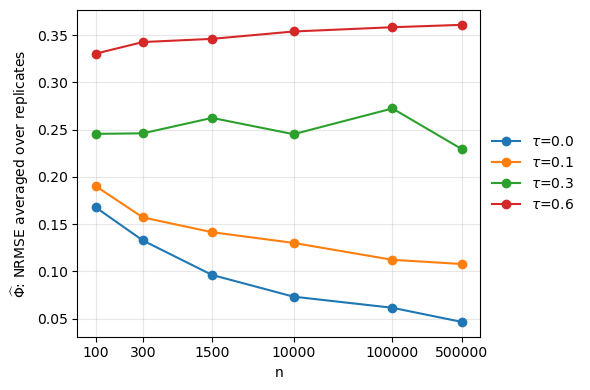

In [40]:
# make sure tau is ordered nicely
df_C_nrmse_plot = df_C_nrmse_summary[df_C_nrmse_summary["algorithm"] == "Greedy search"].copy()
df_C_nrmse_plot = df_C_nrmse_plot.sort_values(["tau", "n"])
n_list = [100, 300, 1500, 10000, 100000, 500000]

fig, ax = plt.subplots(figsize=(6, 4))

for tau in tau_list:
    sub = df_C_nrmse_plot[df_C_nrmse_plot["tau"] == tau].sort_values("n")
    ax.plot(sub["n"], sub["mean_value"], marker="o", label=rf"$\tau$={tau}")

ax.set_xscale("log")
ax.set_xticks(n_list)
ax.set_xticklabels(n_list)
ax.minorticks_off()   # removes the little ticks between n values
ax.set_xlabel("n")

ax.set_ylabel("$\widehat{\Phi}$: NRMSE averaged over replicates")
ax.grid(True, alpha=0.3)

# legend outside
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)

plt.tight_layout()
plt.show()